In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:
df = pd.read_csv('fake_job_postings.csv', engine='python', on_bad_lines='warn')
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0



Fraudulent distribution:
fraudulent
0    0.951566
1    0.048434
Name: proportion, dtype: float64


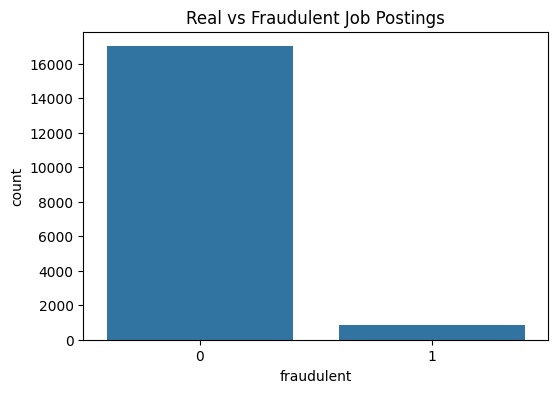

In [8]:
import matplotlib.pyplot as plt
print("\nFraudulent distribution:")
print(df['fraudulent'].value_counts(normalize=True))

# Highly imbalanced → we will use class_weight later
plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent', data=df)
plt.title('Real vs Fraudulent Job Postings')
plt.show()

In [9]:
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

In [10]:
cat_columns = ['location', 'department', 'salary_range', 'employment_type',
               'required_experience', 'required_education', 'industry', 'function']

binary_columns = ['telecommuting', 'has_company_logo', 'has_questions']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [12]:
# Fill NaN in text columns with empty string
for col in text_columns:
    df[col] = df[col].fillna('')

In [13]:
# Combine all text into one column
df['full_text'] = df[text_columns].agg(' '.join, axis=1)

In [14]:
# Fill NaN in categorical columns
for col in cat_columns:
    df[col] = df[col].fillna('missing')

In [15]:
for col in binary_columns:
    df[col] = df[col].fillna(0)

In [16]:
df.isnull().sum()

,0
job_id,0
title,0
location,0
department,0
salary_range,0
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine text columns
df['text'] = df['description'] + ' ' + df['requirements'] + ' ' + df['benefits']

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
text_features = tfidf.fit_transform(df['text'])

In [18]:
#Categorical encoding
df_cat = pd.get_dummies(df[cat_columns], drop_first=True)

In [19]:
num_cols = ['telecommuting', 'has_company_logo', 'has_questions']
df_num = df[num_cols]

In [20]:
# Length of job description
df['desc_length'] = df['description'].apply(len)

# Word count
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Presence of suspicious words
suspicious_words = ['free', 'earn', 'money', 'quick', 'no experience']

for word in suspicious_words:
    df[f'has_{word}'] = df['text'].apply(lambda x: 1 if word in x.lower() else 0)

In [21]:
from scipy.sparse import hstack

X = hstack([text_features, df_cat.values, df_num.values, df[['desc_length','word_count']].values])
y = df['fraudulent']
print(X)
print(y)

<COOrdinate sparse matrix of dtype 'float64'
	with 2269656 stored elements and shape (17880, 10514)>
  Coords	Values
  (0, 1899)	0.553530192333185
  (0, 1800)	0.03881434361751992
  (0, 2070)	0.0394025692548558
  (0, 480)	0.0692927891416422
  (0, 4910)	0.06659492359708309
  (0, 3049)	0.04650179939276019
  (0, 1898)	0.13305373933331538
  (0, 913)	0.05645072143172986
  (0, 1160)	0.10349841082291121
  (0, 2193)	0.0937790191951453
  (0, 1165)	0.04918578383417846
  (0, 2409)	0.08407672977587721
  (0, 4554)	0.02932885353264524
  (0, 2400)	0.0919511397269322
  (0, 4924)	0.0429478058419703
  (0, 4164)	0.09835663232598588
  (0, 4477)	0.02329140476436663
  (0, 1480)	0.1021174228876334
  (0, 1698)	0.07358668784751952
  (0, 1304)	0.11347720280988834
  (0, 2961)	0.029825639191580378
  (0, 4966)	0.06765294768229582
  (0, 807)	0.06524534659525175
  (0, 2115)	0.08393831261588557
  (0, 1706)	0.04977952952094723
  :	:
  (17867, 10513)	123.0
  (17868, 10512)	873.0
  (17868, 10513)	124.0
  (17869, 10512)	4

In [22]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [23]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove URLs
    text = re.sub(r'http[s]?://\S+', ' ', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

In [24]:
print("Cleaning text...")
df['cleaned_text'] = df['full_text'].apply(clean_text)
print("Text cleaning completed.")

Cleaning text...
Text cleaning completed.


In [25]:
!pip install textblob spacy

import pandas as pd
import numpy as np
import re
import spacy
from textblob import TextBlob
from collections import Counter

nlp = spacy.load("en_core_web_sm")

In [26]:
#Lexical features
def lexical_features(text):
    words = text.split()
    sentences = text.split('.')

    return {
        "word_count": len(words),
        "avg_sentence_length": len(words) / (len(sentences) + 1),

        # Suspicious keywords
        "suspicious_words": sum(1 for w in words if w in [
            "earn", "quick", "money", "urgent", "no", "experience", "required"
        ]),

        # Capitalization ratio
        "capital_ratio": sum(1 for w in words if w.isupper()) / (len(words) + 1),

        # Punctuation count
        "exclamation_count": text.count('!'),
        "question_count": text.count('?')
    }

In [27]:
#Syntatic features
def syntactic_features(text):
    doc = nlp(text)

    pos_counts = Counter([token.pos_ for token in doc])

    nouns = pos_counts['NOUN']
    verbs = pos_counts['VERB']

    return {
        "noun_count": nouns,
        "verb_count": verbs,
        "noun_verb_ratio": nouns / (verbs + 1),
        "sentence_count": len(list(doc.sents))
    }

In [28]:
#Semantic Features
def semantic_features(text):
    blob = TextBlob(text)

    return {
        "polarity": blob.sentiment.polarity,
        "subjectivity": blob.sentiment.subjectivity
    }

In [29]:
#Structural Features
def structural_features(text):
    return {
        # Email detection
        "has_email": 1 if re.search(r'\S+@\S+', text) else 0,

        # Phone number detection
        "has_phone": 1 if re.search(r'\d{10}', text) else 0,

        # Salary mention
        "has_salary": 1 if re.search(r'\$\d+|\d+\s?USD|\d+\s?rs', text.lower()) else 0,

        # Company mention
        "has_company": 1 if "company" in text.lower() else 0
    }

In [30]:

#Combine all features
def extract_linguistic_features(text):
    features = {}

    features.update(lexical_features(text))
    features.update(syntactic_features(text))
    features.update(semantic_features(text))
    features.update(structural_features(text))

    return features

In [31]:
#APPLY TO DATASET
linguistic_df = df['description'].apply(extract_linguistic_features)
linguistic_df = pd.DataFrame(linguistic_df.tolist())

linguistic_df.head()

,word_count,avg_sentence_length,suspicious_words,capital_ratio,exclamation_count,question_count,noun_count,verb_count,noun_verb_ratio,sentence_count,polarity,subjectivity,has_email,has_phone,has_salary,has_company
0,124,41.333333,0,0.008000,0,0,39,18,2.052632,2,0.093636,0.470455,0,0,0,0
1,315,18.529412,1,0.003165,4,4,78,38,2.000000,18,0.251323,0.472400,0,0,0,0
2,50,10.000000,0,0.019608,0,0,14,6,2.000000,3,0.486667,0.793333,0,0,0,0
3,346,38.444444,1,0.020173,0,0,117,49,2.340000,9,0.232955,0.518939,0,0,0,1
4,168,33.600000,0,0.059172,0,0,61,13,4.357143,4,0.118636,0.260455,0,0,0,1


In [32]:
#MERGE WITH TF-IDF FEATURES
tfidf_df = pd.DataFrame(text_features.toarray(), columns=tfidf.get_feature_names_out())
final_features = pd.concat([tfidf_df, linguistic_df], axis=1)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = final_features
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9630872483221476


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import MinMaxScaler


In [35]:
X = final_features
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]:,}  rows, {X_train.shape[1]:,} features")
print(f"Test  size : {X_test.shape[0]:,}   rows")
print(f"Fraud ratio (train): {y_train.mean():.2%}")
print(f"Fraud ratio (test) : {y_test.mean():.2%}")


Train size : 14,304  rows, 5,016 features
Test  size : 3,576   rows
Fraud ratio (train): 4.84%
Fraud ratio (test) : 4.84%


In [36]:
# Naive Bayes and LinearSVC need non-negative / scaled features
scaler     = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Scaling complete. Range check:", X_train_sc.min(), "→", X_train_sc.max())


Scaling complete. Range check: 0.0 → 1.0


In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Naïve Bayes"        : MultinomialNB(),
    "SVM (LinearSVC)"    : LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
}

trained = {}
for name, clf in models.items():
    if name in ("Naïve Bayes", "SVM (LinearSVC)"):
        clf.fit(X_train_sc, y_train)
        trained[name] = (clf, X_test_sc)
    else:
        clf.fit(X_train, y_train)
        trained[name] = (clf, X_test)
    print(f" {name} trained.")

 Logistic Regression trained.
 Naïve Bayes trained.
 SVM (LinearSVC) trained.


In [38]:
def evaluate(name, clf, X_te, y_te):
    y_pred = clf.predict(X_te)
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_te)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_score = clf.decision_function(X_te)
    else:
        y_score = y_pred
    return {
        "Model"    : name,
        "Accuracy" : accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall"   : recall_score(y_te, y_pred),
        "F1-Score" : f1_score(y_te, y_pred),
        "AUC"      : roc_auc_score(y_te, y_score),
        "y_pred"   : y_pred,
        "y_score"  : y_score,
    }

results = {}
for name, (clf, X_te) in trained.items():
    results[name] = evaluate(name, clf, X_te, y_test)
    r = results[name]
    print(f"\n── {name} ─────────────────────────────────")
    print(f"  Accuracy : {r['Accuracy']:.4f}")
    print(f"  Precision: {r['Precision']:.4f}")
    print(f"  Recall   : {r['Recall']:.4f}")
    print(f"  F1-Score : {r['F1-Score']:.4f}")
    print(f"  AUC      : {r['AUC']:.4f}")



── Logistic Regression ─────────────────────────────────
  Accuracy : 0.9323
  Precision: 0.4039
  Recall   : 0.8382
  F1-Score : 0.5451
  AUC      : 0.9611

── Naïve Bayes ─────────────────────────────────
  Accuracy : 0.9410
  Precision: 0.4362
  Recall   : 0.7514
  F1-Score : 0.5520
  AUC      : 0.9461

── SVM (LinearSVC) ─────────────────────────────────
  Accuracy : 0.9732
  Precision: 0.7175
  Recall   : 0.7341
  F1-Score : 0.7257
  AUC      : 0.9590


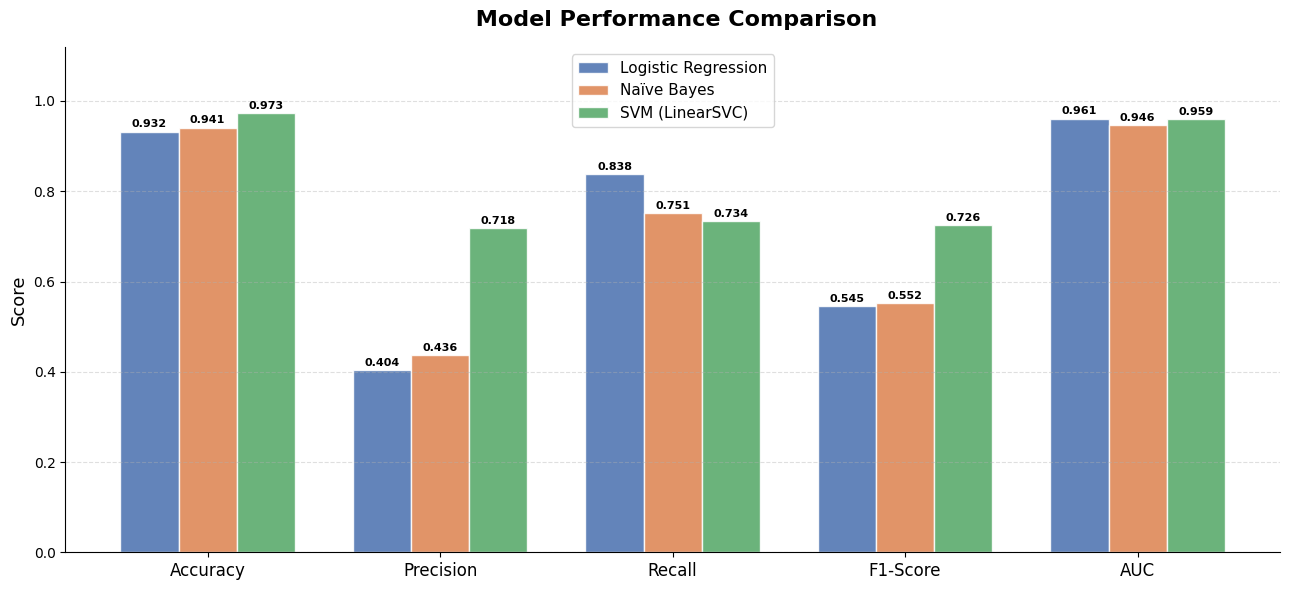

In [39]:
metrics     = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]
model_names = list(results.keys())
x           = np.arange(len(metrics))
width       = 0.25
colors      = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, col) in enumerate(zip(model_names, colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=col, alpha=0.87, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=13)
ax.set_title(" Model Performance Comparison", fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


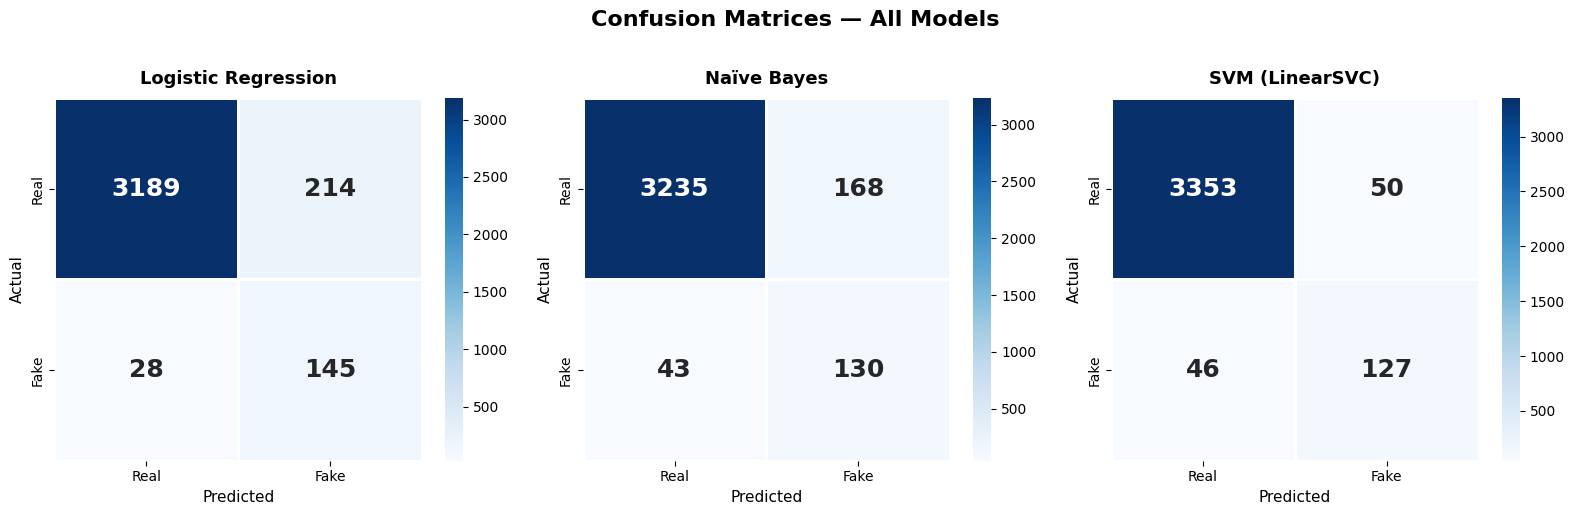

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrices — All Models", fontsize=16, fontweight='bold', y=1.02)

for ax, (name, (clf, X_te)) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                linewidths=1, linecolor='white',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'],
                annot_kws={"size": 18, "weight": "bold"})
    # Add TP / FP / FN / FN labels
    ax.set_title(name, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual",    fontsize=11)

plt.tight_layout()
plt.show()


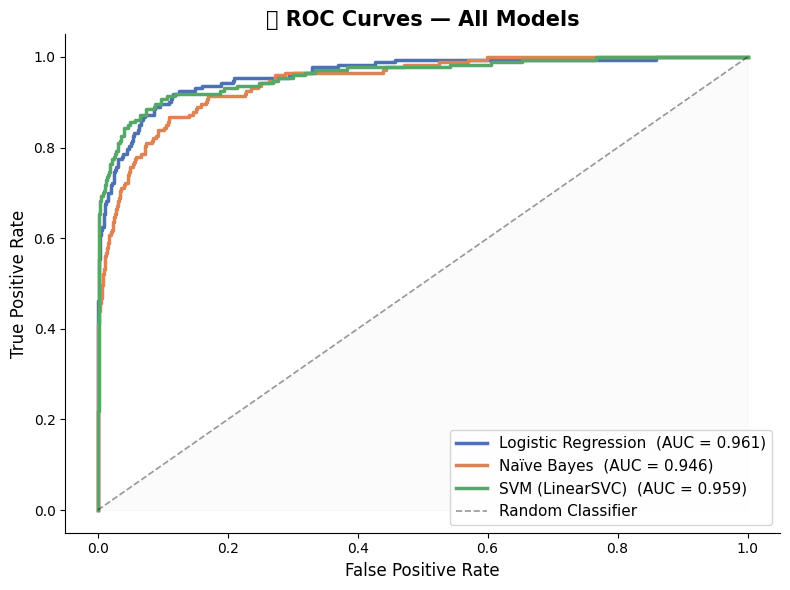

In [41]:
palette = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(8, 6))
for col, (name, r) in zip(palette, results.items()):
    fpr, tpr, _ = roc_curve(y_test, r["y_score"])
    ax.plot(fpr, tpr, color=col, lw=2.5,
            label=f"{name}  (AUC = {r['AUC']:.3f})")

ax.plot([0,1],[0,1], 'k--', alpha=0.4, linewidth=1.2, label="Random Classifier")
ax.fill_between([0,1], [0,0], [0,1], alpha=0.03, color='grey')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate",  fontsize=12)
ax.set_title("📈 ROC Curves — All Models", fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


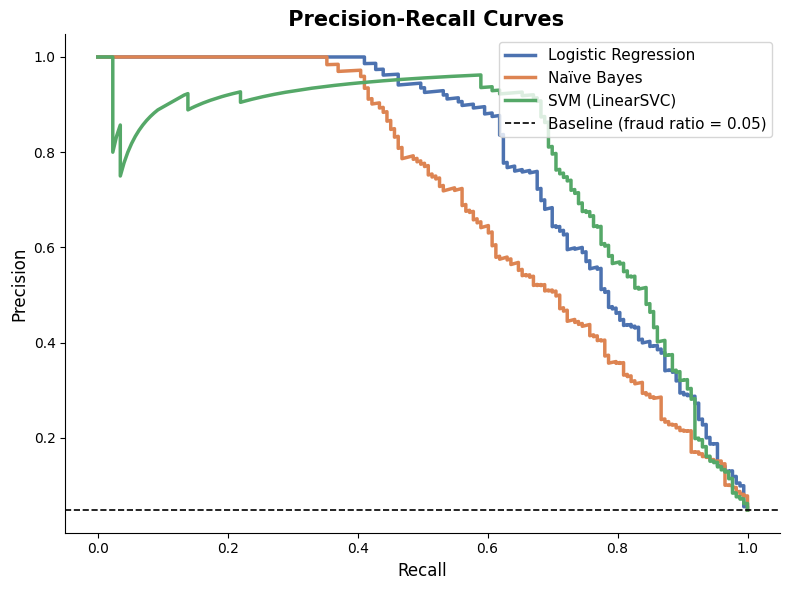

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))
for col, (name, r) in zip(palette, results.items()):
    prec, rec, _ = precision_recall_curve(y_test, r["y_score"])
    ax.plot(rec, prec, color=col, lw=2.5, label=name)

baseline = y_test.mean()
ax.axhline(baseline, color='black', linestyle='--', linewidth=1.2,
           label=f"Baseline (fraud ratio = {baseline:.2f})")
ax.set_xlabel("Recall",    fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title(" Precision-Recall Curves", fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [43]:
best_name = max(results, key=lambda k: results[k]["F1-Score"])
print(f"\n{'='*60}")
print(f"  Best Model  : {best_name}")
print(f"  F1-Score       : {results[best_name]['F1-Score']:.4f}")
print(f"{'='*60}\n")
print(classification_report(
    y_test,
    results[best_name]["y_pred"],
    target_names=["Real (0)", "Fraud (1)"]
))



  Best Model  : SVM (LinearSVC)
  F1-Score       : 0.7257

              precision    recall  f1-score   support

    Real (0)       0.99      0.99      0.99      3403
   Fraud (1)       0.72      0.73      0.73       173

    accuracy                           0.97      3576
   macro avg       0.85      0.86      0.86      3576
weighted avg       0.97      0.97      0.97      3576



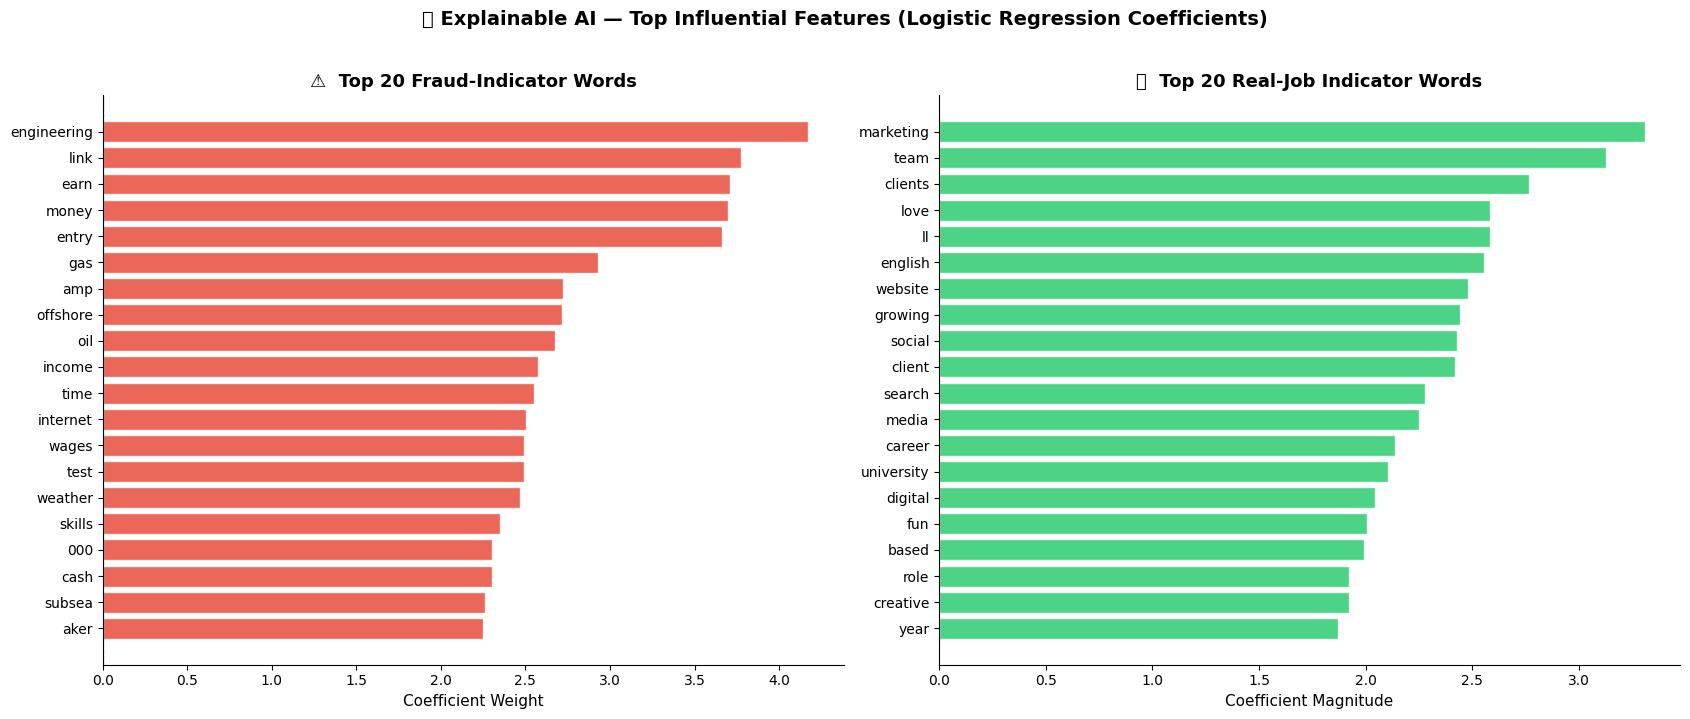


Top 10 Fraud Keywords:
engineering    4.172477
link           3.773704
earn           3.710855
money          3.696083
entry          3.659785
gas            2.927060
amp            2.721188
offshore       2.716999
oil            2.672962
income         2.571928


In [44]:
# Explainable AI
lr_clf      = trained["Logistic Regression"][0]
feature_names = list(final_features.columns)
coefs       = pd.Series(lr_clf.coef_[0], index=feature_names)

top_fraud = coefs.nlargest(20)
top_real  = coefs.nsmallest(20)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle("🔍 Explainable AI — Top Influential Features (Logistic Regression Coefficients)",
             fontsize=14, fontweight='bold', y=1.02)

# — Fraud indicators ——————————————————————————
axes[0].barh(top_fraud.index[::-1], top_fraud.values[::-1],
             color='#E74C3C', alpha=0.85, edgecolor='white')
axes[0].set_title("⚠️  Top 20 Fraud-Indicator Words", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Coefficient Weight",  fontsize=11)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].spines[['top','right']].set_visible(False)

# — Real indicators ———————————————————————————
axes[1].barh(top_real.index[::-1], top_real.values[::-1] * -1,
             color='#2ECC71', alpha=0.85, edgecolor='white')
axes[1].set_title("✅  Top 20 Real-Job Indicator Words", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Coefficient Magnitude", fontsize=11)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\nTop 10 Fraud Keywords:")
print(top_fraud.head(10).to_string())


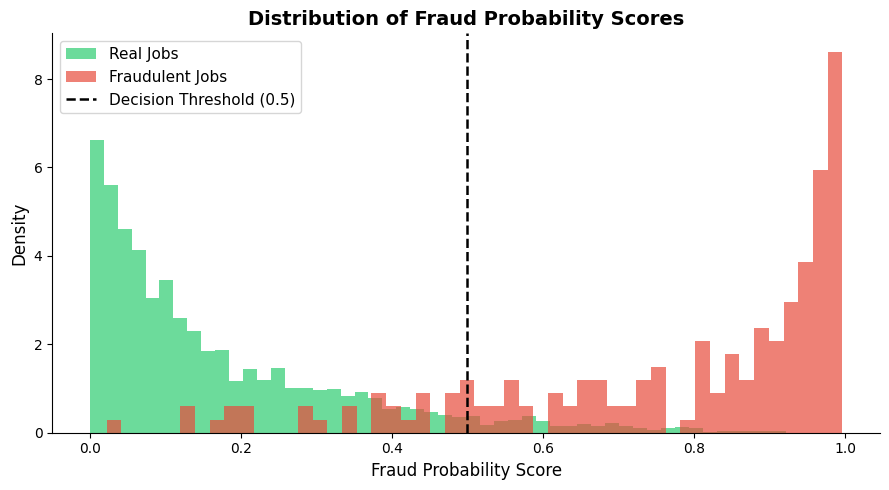

In [45]:
lr_clf_obj = trained["Logistic Regression"][0]
lr_X_te    = trained["Logistic Regression"][1]
probs      = lr_clf_obj.predict_proba(lr_X_te)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(probs[y_test == 0], bins=50, alpha=0.7,
        color='#2ECC71', label='Real Jobs',       density=True)
ax.hist(probs[y_test == 1], bins=50, alpha=0.7,
        color='#E74C3C', label='Fraudulent Jobs', density=True)
ax.axvline(0.5, color='black', linestyle='--',
           linewidth=1.8, label='Decision Threshold (0.5)')
ax.set_xlabel("Fraud Probability Score", fontsize=12)
ax.set_ylabel("Density",                 fontsize=12)
ax.set_title("Distribution of Fraud Probability Scores", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


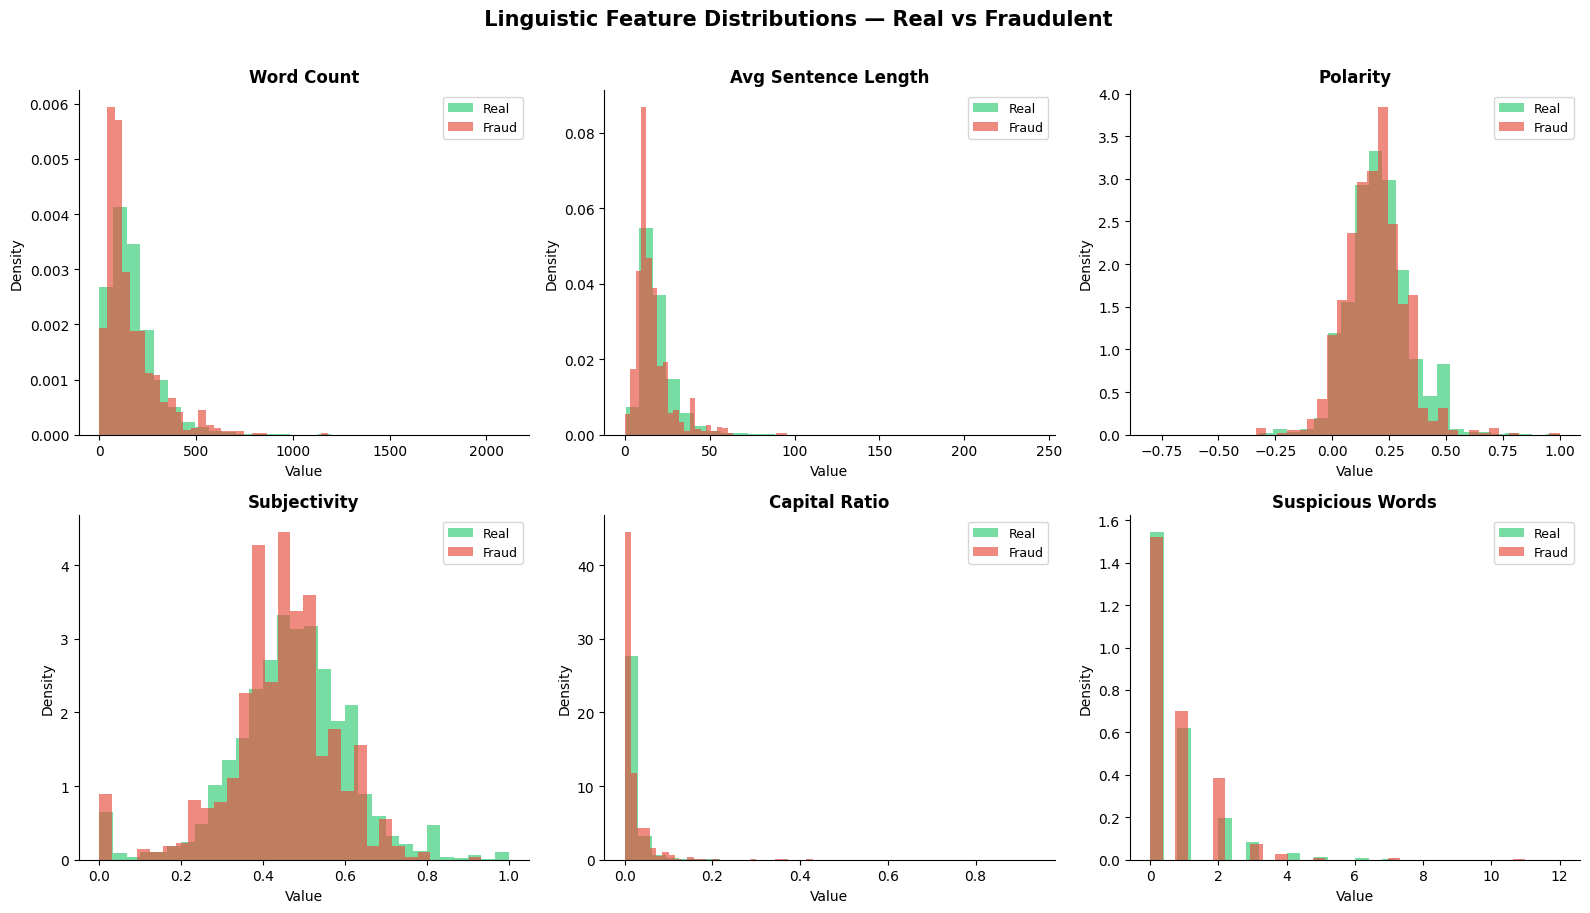

In [46]:
ling_cols = ['word_count', 'avg_sentence_length', 'polarity',
             'subjectivity', 'capital_ratio', 'suspicious_words']
available = [c for c in ling_cols if c in linguistic_df.columns]

plot_df = linguistic_df[available].copy()
plot_df['fraudulent'] = df['fraudulent'].values

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(" Linguistic Feature Distributions — Real vs Fraudulent",
             fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

clr = {0: '#2ECC71', 1: '#E74C3C'}
lbl = {0: 'Real',    1: 'Fraud'}

for ax, col in zip(axes, available):
    for flag, color in clr.items():
        data = plot_df[plot_df['fraudulent'] == flag][col].dropna()
        ax.hist(data, bins=30, alpha=0.65,
                color=color, label=lbl[flag], density=True)
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel("Value",   fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


Logistic Regression        CV F1 = 0.5142  ±  0.0150
Naïve Bayes                CV F1 = 0.4996  ±  0.0316
SVM (LinearSVC)            CV F1 = 0.6953  ±  0.0229


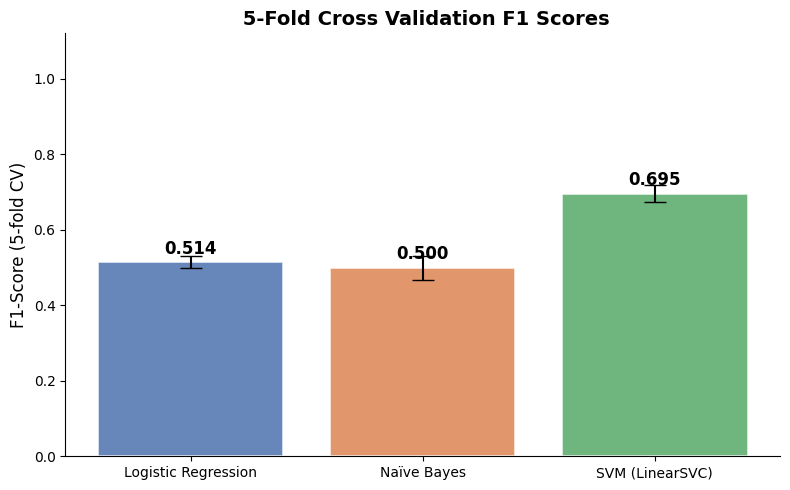

In [47]:
cv_results = {}
for name, (clf, _) in trained.items():
    X_cv = X_train_sc if name in ("Naïve Bayes", "SVM (LinearSVC)") else X_train
    scores = cross_val_score(clf, X_cv, y_train, cv=5, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s}  CV F1 = {scores.mean():.4f}  ±  {scores.std():.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
names_cv = list(cv_results.keys())
means    = [cv_results[n].mean() for n in names_cv]
stds     = [cv_results[n].std()  for n in names_cv]
bars     = ax.bar(names_cv, means, yerr=stds, capsize=8,
                  color=['#4C72B0','#DD8452','#55A868'],
                  alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
            f'{m:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel("F1-Score (5-fold CV)", fontsize=12)
ax.set_title(" 5-Fold Cross Validation F1 Scores", fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


In [48]:
def predict_job(text,
                clf=lr_clf_obj,
                sc=scaler,
                tf=tfidf,
                lf_fn=extract_linguistic_features,
                feature_cols=list(final_features.columns)):
    """
    Input : raw job ad text (string)
    Output: (label, fraud_probability, top_5_influential_words)
    """
    # TF-IDF vector
    tfidf_vec = tf.transform([text])
    tfidf_row = pd.DataFrame(tfidf_vec.toarray(), columns=tf.get_feature_names_out())
    # Linguistic features
    ling_row  = pd.DataFrame([lf_fn(text)])
    # Combine & align
    row = pd.concat([tfidf_row, ling_row], axis=1)
    row = row.reindex(columns=feature_cols, fill_value=0)
    # Probability
    prob  = clf.predict_proba(row)[0][1]
    label = " FRAUDULENT" if prob >= 0.5 else " GENUINE"
    # Top influential words present in this posting
    coef_s = pd.Series(clf.coef_[0], index=feature_cols)
    present = row.columns[row.iloc[0] > 0]
    top5    = coef_s[present].nlargest(5).index.tolist()
    return label, round(prob, 4), top5

# ── Test on a suspicious posting ─────────────────────────────
sample_fake = """
Earn up to $5000/week from home! No experience required. Urgent hiring!
We need motivated individuals to make quick money online.
Send a registration fee of $50 to get started.
Contact: earn.quick.jobs@gmail.com. Apply now! Free training provided!
"""

label, prob, top5 = predict_job(sample_fake)
print("=" * 55)
print("   PREDICTION DEMO — Suspicious Posting")
print("=" * 55)
print(f"  Prediction        : {label}")
print(f"  Fraud Probability : {prob:.2%}")
print(f"  Top Flagged Words : {top5}")

# ── Test on a genuine posting ─────────────────────────────────
sample_real = """
We are hiring a Senior Software Engineer with 4+ years of experience
in Python, Django, and REST APIs. The role involves architecting
microservices, collaborating with product teams, and ensuring code
quality. We offer competitive salary, health benefits, and flexible
remote work. Apply via our careers portal with your updated resume.
"""

label2, prob2, top52 = predict_job(sample_real)
print("\n" + "=" * 55)
print("  PREDICTION DEMO — Genuine Posting")
print("=" * 55)
print(f"  Prediction        : {label2}")
print(f"  Fraud Probability : {prob2:.2%}")
print(f"  Top Flagged Words : {top52}")
print("=" * 55)


   PREDICTION DEMO — Suspicious Posting
  Prediction        :  FRAUDULENT
  Fraud Probability : 92.34%
  Top Flagged Words : ['earn', 'money', 'started', 'online', 'send']

  PREDICTION DEMO — Genuine Posting
  Prediction        :  GENUINE
  Fraud Probability : 28.26%
  Top Flagged Words : ['product', 'benefits', 'work', 'hiring', 'quality']


In [49]:
summary = pd.DataFrame([{
    "Model"    : r["Model"],
    "Accuracy" : f"{r['Accuracy']:.4f}",
    "Precision": f"{r['Precision']:.4f}",
    "Recall"   : f"{r['Recall']:.4f}",
    "F1-Score" : f"{r['F1-Score']:.4f}",
    "AUC-ROC"  : f"{r['AUC']:.4f}",
} for r in results.values()])

print("\n" + "="*70)
print("                 MODEL PERFORMANCE SUMMARY")
print("="*70)
print(summary.to_string(index=False))
print("="*70)
best = max(results, key=lambda k: results[k]["F1-Score"])
print(f"\n  Recommended Model  : {best}")
print(f"  Best F1-Score        : {results[best]['F1-Score']:.4f}")
print(f"  Best AUC             : {results[best]['AUC']:.4f}")



                 MODEL PERFORMANCE SUMMARY
              Model Accuracy Precision Recall F1-Score AUC-ROC
Logistic Regression   0.9323    0.4039 0.8382   0.5451  0.9611
        Naïve Bayes   0.9410    0.4362 0.7514   0.5520  0.9461
    SVM (LinearSVC)   0.9732    0.7175 0.7341   0.7257  0.9590

  Recommended Model  : SVM (LinearSVC)
  Best F1-Score        : 0.7257
  Best AUC             : 0.9590
